# Finite Element Basis

This notebook demonstrates the application of `Basis` class from `/utils/finite_element.py`. Specifically, we will show case `LagrangeBasis`, a sub-class of `Basis`. Conceptually, the class serve as the standardized basis that can be transform to/from the basis used by each of the simplices.

The basis in this case refers to a set of linearly independent functions that can well approximate any function on the domain of each element. In the case of orthogonal griding in FDM, each simulation element is a rectangle making it easier to define a proper basis that is easy to handle no matter which element is currently worked on. However, to leverage the full potential of FEM, the simplex triangulation is used. The non-orthogonal domain make the transformation pretty cumbersome especially how to treate continuity at the edges between the elements. Hence, for the demo, we will use Lagrange polynomial basis which has a nice properties that the functions are easily defined by the corners of simplices. Since it is a polynomial style basis, the differentiations are simple and deterministic. It also has a very nice property at the element edges that the cross-section is also a Lagrange polynomial basis of the lower dimension simplex.

Arbitrarily, we choose the standard basis to be the Lagrange polynoimial basis on simplex that is defined by the origin and all unit Cartesian basis vectors, e.g., $\{(0,), (1,)\}$ for 1D, $\{(0, 0), (1, 0), (0, 1)\}$ for 2D, $\{(0, 0, 0), (1, 0, 0), (0, 1, 0), (1, 0, 0)\}$ for 3D, etc. The following code show how to initialize basis object in standard simplex with certain polynomial orders (we choose `domain_rank = 3` for the demo) in 1D (`d = 1`) and 2D (`d = 2`) as well as the visualization of those bases. Also, the 2D visualization use `plt.imshow` which reversed the $y$ axis.

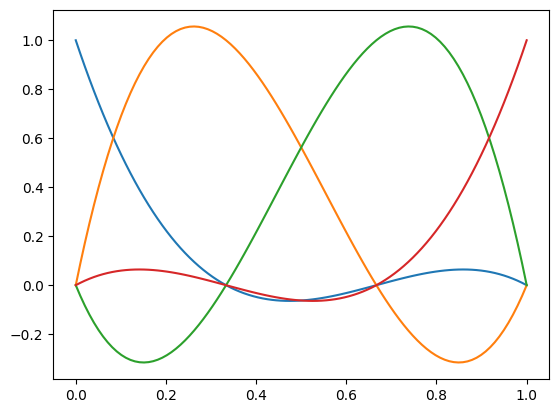

In [1]:
from utils.finite_element import LagrangeBasis

basis_1d = LagrangeBasis(1, 3)
basis_1d.visualize()

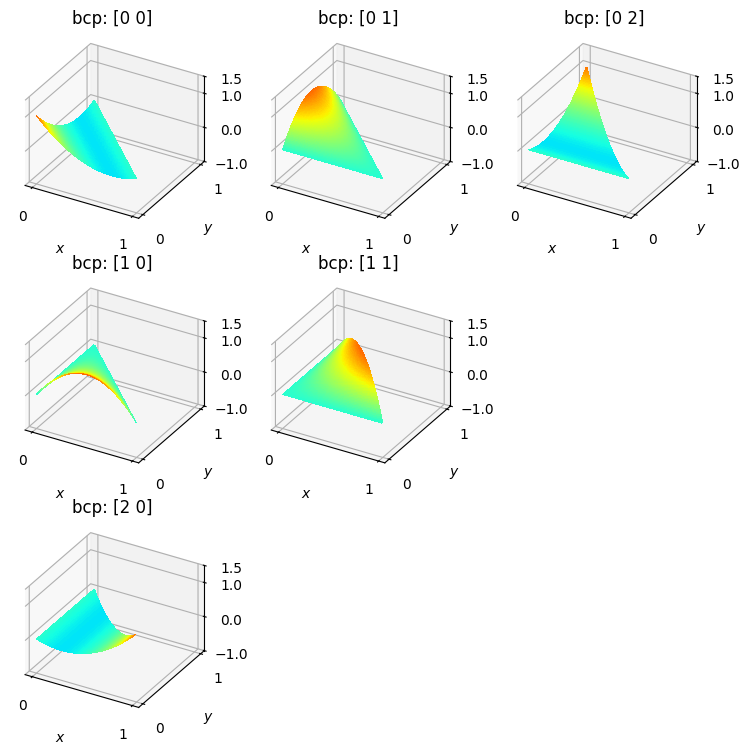

In [2]:
basis_2d = LagrangeBasis(2, 2)
basis_2d.visualize()

One should notice that the initialization of 2D version take significantly more time than the 1D version. There are multiple reasons that contribute to that. The first is that for the polynomial order $P$ and dimension $D$ the number of function in the basis is $\binom{P+D}{D}$. Hence, for our example, the 1D has 4 functions while 2D has 10 functions. Another reason is that the Lagrange polynomials are not orthogonal. They are also not normalized, i.e., we trade the flexibility of the basis with the computational over head required to calculate things like basis overlap matrices which become more expensive with the dimension.

Next, we will show some of the standard function that will be useful.

## 1. Interpolation (projection to the space span by the basis functions)

For any scalar function (tensor value function can be treated as set of scalar functions) that is well defined over the whole domain of the standard element, we can project it to the basis function representation. The following codes show how to perform interpolation of 

$f_{1d}(x) = e^{-2x^2}$ 

and 

$f_{2d}(x, y) = e^{-2(x^2 + y^2)}$

as examples for 1D and 2D cases, respectively.

In [3]:
import numpy as np

fun_gauss_1d = lambda x: np.exp(-2 * np.array(x)**2)
rep_gauss_1d = basis_1d.element_fun2rep(fun_gauss_1d)
rep_gauss_1d

array([1.00398838, 0.79955182, 0.4122028 , 0.1458998 ])

In [4]:
fun_gauss_2d = lambda x: np.exp(-2 * np.sum(np.array(x)**2, axis = -1, keepdims = True))
rep_gauss_2d = basis_2d.element_fun2rep(fun_gauss_2d)
rep_gauss_2d

array([1.09736178, 0.64961862, 0.01200827, 0.64961862, 0.37400162,
       0.01200827])

To visualize the representation, we can reconstruct the function back as a linear combination of the basis functions.

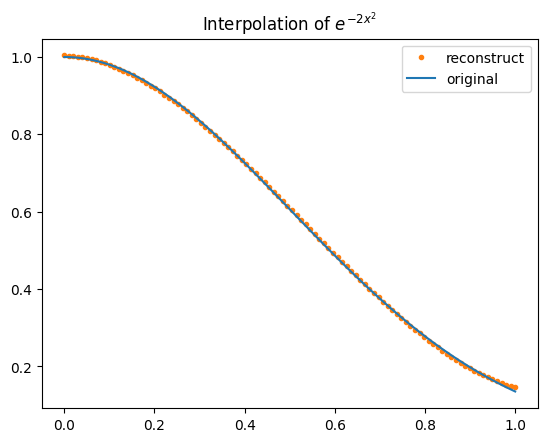

In [5]:
import matplotlib.pyplot as plt

rec_gauss_1d = basis_1d.element_rep2fun(rep_gauss_1d)

x = np.linspace(0, 1, 100)

plt.figure()
plt.plot(x, rec_gauss_1d(x), '.C1', label = 'reconstruct')
plt.plot(x, fun_gauss_1d(x), '-C0', label = 'original')
plt.title(r'Interpolation of $e^{-2x^2}$')
plt.legend()
plt.show()

The 2D one is slightly more difficult to visualize since we need to plot it in 3D.

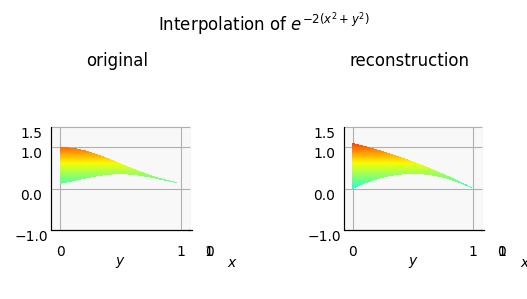

In [12]:
from matplotlib import cm

rec_gauss_2d = basis_2d.element_rep2fun(rep_gauss_2d)

x, y = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
x, y = x.flatten(), y.flatten()
x, y = x[x + y <= 1], y[x + y <= 1]

fig, axs = plt.subplots(1, 2, subplot_kw = {'projection': '3d', 'proj_type': 'ortho'}, figsize = (6, 3))

for ax, fun, title in zip(axs, [fun_gauss_2d, rec_gauss_2d], ['original', 'reconstruction']):
    z = fun(np.stack([x, y], axis = -1)).flatten()

    ax.plot_trisurf(x, y, z, cmap = cm.jet, linewidth = 0, antialiased = False, vmin = -1, vmax = 1.5)
    ax.set_title(title)
    ax.set_xlabel(r'$x$')
    ax.get_xaxis().set_ticks([0, 1])
    ax.set_ylabel(r'$y$')
    ax.get_yaxis().set_ticks([0, 1])
    ax.get_zaxis().set_ticks([-1, 0, 1, 1.5])

fig.suptitle(r'Interpolation of $e^{-2(x^2+y^2)}$')
fig.subplots_adjust(wspace = 0.2, hspace = 0.2)
fig.tight_layout()
fig.show()

## 2. Differentiation of representation

Because basis functions chosen are differentiable, they has their own derivatives. Furthermore, since the differentiation is a linear operation, any linear combination of basis functions has derivative equal to the same linear combination of the derivatives of those basis functions. However, this is not quite convenient to have separate bases for a function and derivatives. Hence, instead of using the derivatives of basis directly, we interpolate those derivatives back as a linear combination of basis function. This process is the same as the interpolation shown above, but it can be done at the initialization of basis object since we know the function before hand. One can also cache the information if the basis is frequently used.

The following code show how to apply this differentiation to the representation we get from the previous section. The `dim` parameter indicates the axis of differentiation running from `0` to `d-1`.

In [13]:
rep_prime_x_gauss_1d = basis_1d.diff(rep_gauss_1d, dim = 0)
rep_prime_x_gauss_2d = basis_2d.diff(rep_gauss_2d, dim = 0)
rep_prime_y_gauss_2d = basis_2d.diff(rep_gauss_2d, dim = 1)

Since we know that

$\partial_xf_{1d}(x) = -4xe^{-2x^2}$,

$\partial_xf_{2d}(x, y) = -4xe^{-2(x^2 + y^2)}$

and

$\partial_yf_{2d}(x, y) = -4ye^{-2(x^2 + y^2)}$,

we can directly compare them to the reconstruction from the representation.

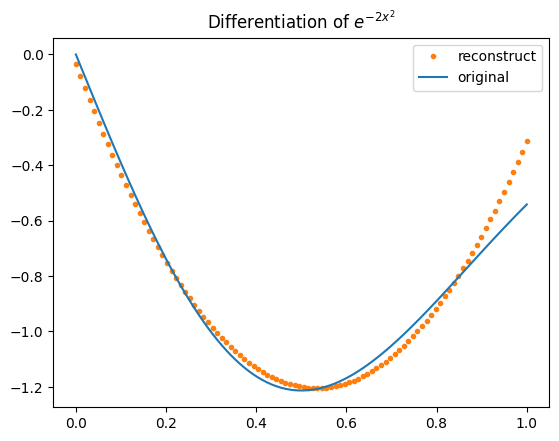

In [14]:
rec_prime_x_gauss_1d = basis_1d.element_rep2fun(rep_prime_x_gauss_1d)
fun_prime_x_gauss_1d = lambda x: -4*np.array(x) * np.exp(-2*np.array(x)**2)

x = np.linspace(0, 1, 100)

plt.figure()
plt.plot(x, rec_prime_x_gauss_1d(x), '.C1', label = 'reconstruct')
plt.plot(x, fun_prime_x_gauss_1d(x), '-C0', label = 'original')
plt.title(r'Differentiation of $e^{-2x^2}$')
plt.legend()
plt.show()

In [15]:
basis_2d.derivatives[0]

array([[-3.00000000e+00,  1.11022302e-15,  0.00000000e+00,
         1.66533454e-16, -2.22044605e-16,  2.00000000e+00],
       [-1.00000000e+00, -2.00000000e+00,  0.00000000e+00,
        -1.00000000e+00,  2.00000000e+00,  2.00000000e+00],
       [ 1.00000000e+00, -8.00000000e+00,  0.00000000e+00,
        -2.00000000e+00,  4.00000000e+00,  2.00000000e+00],
       [-1.00000000e+00, -6.93889390e-16,  0.00000000e+00,
        -1.00000000e+00,  7.77156117e-16,  2.00000000e+00],
       [ 1.00000000e+00, -2.00000000e+00,  0.00000000e+00,
        -2.00000000e+00,  2.00000000e+00,  2.00000000e+00],
       [ 1.00000000e+00,  4.44089210e-16,  0.00000000e+00,
        -2.00000000e+00,  8.88178420e-16,  2.00000000e+00]])

In [16]:
basis_2d.derivatives[1]

array([[-3.00000000e+00,  4.00000000e+00, -1.00000000e+00,
         5.55111512e-16, -5.55111512e-16,  0.00000000e+00],
       [-1.00000000e+00, -6.17561557e-16,  1.00000000e+00,
         7.77156117e-16, -7.77156117e-16,  0.00000000e+00],
       [ 1.00000000e+00, -4.00000000e+00,  3.00000000e+00,
        -7.77156117e-16,  7.77156117e-16,  0.00000000e+00],
       [-1.00000000e+00,  2.00000000e+00, -1.00000000e+00,
        -2.00000000e+00,  2.00000000e+00,  0.00000000e+00],
       [ 1.00000000e+00, -2.00000000e+00,  1.00000000e+00,
        -2.00000000e+00,  2.00000000e+00,  0.00000000e+00],
       [ 1.00000000e+00, -6.52256027e-16, -1.00000000e+00,
        -4.00000000e+00,  4.00000000e+00,  0.00000000e+00]])

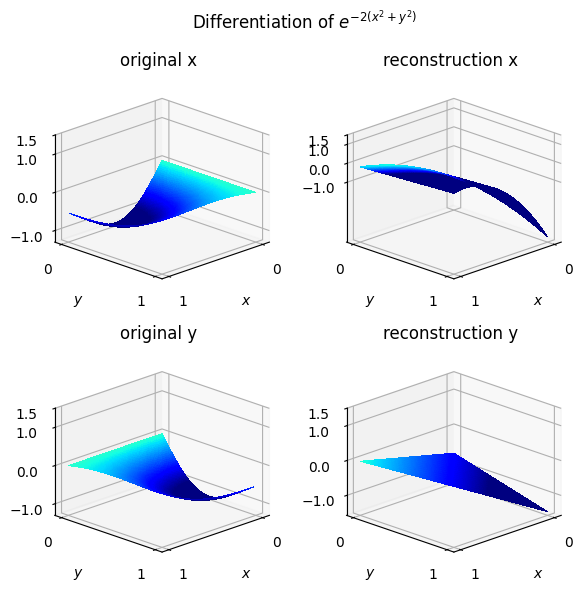

In [22]:
fun_prime_x_gauss_2d = lambda x: -4 * np.array(x)[..., 0:1] * np.exp(-2 * np.sum(np.array(x)**2, axis = -1, keepdims = True))
rep_prime_x_gauss_2d = basis_2d.diff(rep_gauss_2d, dim = 0)
rec_prime_x_gauss_2d = basis_2d.element_rep2fun(rep_prime_x_gauss_2d)

fun_prime_y_gauss_2d = lambda x: -4 * np.array(x)[..., 1:2] * np.exp(-2 * np.sum(np.array(x)**2, axis = -1, keepdims = True))
rep_prime_y_gauss_2d = basis_2d.diff(rep_gauss_2d, dim = 1)
rec_prime_y_gauss_2d = basis_2d.element_rep2fun(rep_prime_y_gauss_2d)


x, y = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
x, y = x.flatten(), y.flatten()
x, y = x[x + y <= 1], y[x + y <= 1]

fig, axs = plt.subplots(2, 2, subplot_kw = {'projection': '3d', 'proj_type': 'ortho'}, figsize = (6, 6))

for ax, fun, title in zip(axs.ravel(), 
                          [fun_prime_x_gauss_2d, rec_prime_x_gauss_2d, fun_prime_y_gauss_2d, rec_prime_y_gauss_2d], 
                          ['original x', 'reconstruction x', 'original y', 'reconstruction y']):
    z = fun(np.stack([x, y], axis = -1)).flatten()

    ax.plot_trisurf(x, y, z, cmap = cm.jet, linewidth = 0, antialiased = False, vmin = -1, vmax = 1.5)
    ax.set_title(title)
    ax.set_xlabel(r'$x$')
    ax.get_xaxis().set_ticks([0, 1])
    ax.set_ylabel(r'$y$')
    ax.get_yaxis().set_ticks([0, 1])
    ax.get_zaxis().set_ticks([-1, 0, 1, 1.5])

fig.suptitle(r'Differentiation of $e^{-2(x^2+y^2)}$')
fig.subplots_adjust(wspace = 0.2, hspace = 0.2)
fig.tight_layout()
fig.show()

## 3. Multiplication of Representation